In [ ]:
#-------------------------------------------------------------------------------

# Step 0: Imports and Installations

#-------------------------------------------------------------------------------


# ==============================
# Install Required Packages
# ==============================
!pip install -q pypdf pytesseract pdf2image pillow sentence-transformers transformers accelerate pymupdf langchain langchain-community faiss-cpu bitsandbytes sentencepiece

# ==============================
# Core Libraries
# ==============================
import numpy as np
import pandas as pd
import copy
import re
import os
import torch
import fitz

# ==============================
# Scikit-learn (ML + Metrics)
# ==============================
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ==============================
# XGBoost
# ==============================
from xgboost import XGBClassifier

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# ==============================
# Transformers (LLM / RAG)
# ==============================
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForCausalLM,
    pipeline,
    BitsAndBytesConfig
)

# ==============================
# Embeddings + Vector Search (RAG)
# ==============================
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import faiss

# ==============================
# PDF + OCR Handling (RAG)
# ==============================
from pypdf import PdfReader
from pdf2image import convert_from_path
import pytesseract
from PIL import Image

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

# ==============================
# Colab File Upload
# ==============================
from google.colab import files, drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# #-------------------------------------------------------------------------------

# # MODEL LOADING

# #-------------------------------------------------------------------------------

# import joblib

# MODEL_SAVE_PATH = "/content/drive/MyDrive/final_diabetes_model.pkl"
# final_model = joblib.load(MODEL_SAVE_PATH)

# print("Model loaded.")



---



In [ ]:
#-------------------------------------------------------------------------------

# STEP 1: Dataset Acquisition (PIMA Indian Diabetes Dataset)

#-------------------------------------------------------------------------------

import pandas as pd

path = "/content/drive/MyDrive/diabetes.csv"
df = pd.read_csv(path)

print("Shape:", df.shape)
print("\n-----------------------------------")

print("\nColumns:")
print(df.columns.tolist())
print("\n-----------------------------------")

print("\nFirst 5 rows:")
df.head()

In [ ]:
#-------------------------------------------------------------------------------

# STEP 2: Data Cleaning

#-------------------------------------------------------------------------------

df_clean = df.copy()

invalid_zero_cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df_clean[invalid_zero_cols] = df_clean[invalid_zero_cols].replace(0, np.nan)

for col in invalid_zero_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean.drop_duplicates(inplace=True)

print("Missing values after cleaning:")
print(df_clean.isna().sum())

print("\nShape after cleaning:", df_clean.shape)

In [ ]:
#-------------------------------------------------------------------------------

# STEP 3: Feature Validation

#-------------------------------------------------------------------------------


X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

assert "Outcome" not in X.columns, "Target leakage detected"

print("Feature columns:")
print(X.columns.tolist())

print("\nFeature variances:")
print(X.var())

print("\nLabel distribution:")
print(y.value_counts())

In [ ]:
#-------------------------------------------------------------------------------

# STEP 4: Stratified K-Fold Setup + Scaling Inside Each Fold

#-------------------------------------------------------------------------------


k_folds = 5

skf = StratifiedKFold(
    n_splits=k_folds,
    shuffle=True,
    random_state=42
)

fold = 1
for train_idx, val_idx in skf.split(X, y):

    print(f"Fold {fold}")

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()
    scaler.fit(X_train)

    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    print("Train label distribution:")
    print(y_train.value_counts(normalize=True))
    print("Validation label distribution:")
    print(y_val.value_counts(normalize=True))
    print("-" * 40)

    fold += 1

In [ ]:
#-------------------------------------------------------------------------------

# STEP 5: Model Training with Stratified K-Fold (Correct Version)

#-------------------------------------------------------------------------------

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, solver="liblinear", class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=np.bincount(y)[0] / np.bincount(y)[1],
        eval_metric="logloss",
        random_state=42
    )
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():

    metrics = {
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1": [],
        "roc_auc": []
    }

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if name == "LogisticRegression":
            scaler = StandardScaler()
            scaler.fit(X_train)
            X_train = scaler.transform(X_train)
            X_test = scaler.transform(X_test)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        metrics["accuracy"].append(accuracy_score(y_test, y_pred))
        metrics["precision"].append(precision_score(y_test, y_pred))
        metrics["recall"].append(recall_score(y_test, y_pred))
        metrics["f1"].append(f1_score(y_test, y_pred))
        metrics["roc_auc"].append(roc_auc_score(y_test, y_prob))

    results[name] = {
        metric: f"{np.mean(values):.4f} ± {np.std(values):.4f}"
        for metric, values in metrics.items()
    }

results_df = pd.DataFrame(results).T
print(results_df)

In [ ]:
#-------------------------------------------------------------------------------

# STEP 6: Nested Cross-Validation for XGBoost

#-------------------------------------------------------------------------------




outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [3, 4],
    "learning_rate": [0.03, 0.05],
    "gamma": [0, 1]
}

outer_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": []
}

for train_idx, test_idx in outer_cv.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    neg, pos = np.bincount(y_train)
    scale_pos_weight = neg / pos

    model = XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    )

    grid = GridSearchCV(
        model,
        param_grid,
        cv=inner_cv,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    outer_metrics["accuracy"].append(accuracy_score(y_test, y_pred))
    outer_metrics["precision"].append(precision_score(y_test, y_pred))
    outer_metrics["recall"].append(recall_score(y_test, y_pred))
    outer_metrics["f1"].append(f1_score(y_test, y_pred))
    outer_metrics["roc_auc"].append(roc_auc_score(y_test, y_prob))

print("Nested CV Final Results (Mean ± Std):")
for metric in outer_metrics:
    print(f"{metric}: {np.mean(outer_metrics[metric]):.4f} ± {np.std(outer_metrics[metric]):.4f}")

#These are your true performance estimates.

In [ ]:
#-------------------------------------------------------------------------------

#  Step 7: Retrain final model on full dataset using best hyperparameters

#-------------------------------------------------------------------------------


neg, pos = np.bincount(y)
scale_pos_weight = neg / pos

final_grid = GridSearchCV(
    XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ),
    param_grid,
    cv=inner_cv,
    scoring="f1",
    n_jobs=-1
)

final_grid.fit(X, y)

final_model = final_grid.best_estimator_

print("Final Model Trained on Full Dataset")
print("Best Parameters:", final_grid.best_params_)

#-------------------------------------------------------------------------------

# METRICS FOR FINAL MODEL

#-------------------------------------------------------------------------------


# Predict on full dataset
y_pred = final_model.predict(X)
y_prob = final_model.predict_proba(X)[:, 1]

# Compute metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
roc_auc = roc_auc_score(y, y_prob)

print("Final Model Performance (Full Dataset Evaluation)")
print("--------------------------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

#I used nested cross-validation to estimate true performance. After selecting optimal hyperparameters, I retrained the model on the full dataset to build the final deployable model

In [ ]:
#-------------------------------------------------------------------------------

# SAVING MODEL

#-------------------------------------------------------------------------------

import joblib

MODEL_SAVE_PATH = "/content/drive/MyDrive/final_diabetes_model.pkl"
joblib.dump(final_model, MODEL_SAVE_PATH)

print("Model saved successfully.")

In [ ]:
#-------------------------------------------------------------------------------

# THRESHOLDS

#-------------------------------------------------------------------------------

def clinical_decision(model, patient_features):
    """
    Returns structured clinical decision output.
    Ensures correct shape and consistent inference.
    """

    patient_features = np.array(patient_features)

    if patient_features.ndim == 1:
        patient_features = patient_features.reshape(1, -1)

    if patient_features.shape[1] != 8:
        raise ValueError("Expected 8 features: Pregnancies, Glucose, BloodPressure, "
                         "SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age")

    y_prob = model.predict_proba(patient_features)[0][1]
    y_pred = int(y_prob >= 0.5)

    if y_prob < 0.3:
        risk_level = "Low Risk"
    elif y_prob < 0.7:
        risk_level = "Moderate Risk"
    else:
        risk_level = "High Risk"

    decision = {
        "prediction_label": "Diabetic" if y_pred == 1 else "Non-Diabetic",
        "prediction_binary": y_pred,
        "probability": round(float(y_prob), 4),
        "risk_category": risk_level
    }

    return decision

In [ ]:
#-------------------------------------------------------------------------------

# STEP 8: User Input Interface + Inference Pipeline

#-------------------------------------------------------------------------------


feature_names = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

def get_user_input():
    user_data = []
    for feature in feature_names:
        value = float(input(f"Enter {feature}: "))
        user_data.append(value)
    return np.array(user_data).reshape(1, -1)

def predict_diabetes(user_input):
    prediction = final_model.predict(user_input)[0]
    probability = final_model.predict_proba(user_input)[0][1]
    return prediction, probability


#---------------------------------------------------------------------------ONLY IF YOU WANNA ENTER CUSTOM VALUES---------------------------------------------------------------------------#

# # ---- RUN PIPELINE ----
# user_input = get_user_input()
# prediction, probability = predict_diabetes(user_input)

# # ---- OUTPUT ----
# if prediction == 1:
#     print(f"\nPrediction: DIABETIC")
# else:
#     print(f"\nPrediction: NON-DIABETIC")

# print(f"Diabetes Probability: {probability:.4f}")
#---------------------------------------------------------------------------ONLY IF YOU WANNA ENTER CUSTOM VALUES---------------------------------------------------------------------------#

In [ ]:
#---------------------------------------------------------------------------ONLY IF YOU WANNA ENTER STATIC VALUES---------------------------------------------------------------------------#
test_patient = [6,165,88,35,210,36.5,0.95,52]
decision_output = clinical_decision(final_model, test_patient)
#---------------------------------------------------------------------------ONLY IF YOU WANNA ENTER STATIC VALUES---------------------------------------------------------------------------#


#---------------------------------------------------------------------------ONLY IF YOU WANNA ENTER CUSTOM VALUES---------------------------------------------------------------------------#
# decision_output = clinical_decision(final_model, user_input)
#---------------------------------------------------------------------------ONLY IF YOU WANNA ENTER CUSTOM VALUES---------------------------------------------------------------------------#

print("Final Decision:")
print(decision_output)

In [ ]:
y_pred = final_model.predict(X)

cm = confusion_matrix(y, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
explainer = shap.Explainer(final_model)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)



---



---



---



---



---



---

#RAG

---



---



---



---



---



---



In [ ]:
# #-------------------------------------------------------------------------------

# # LOADING RAG LAYER

# #-------------------------------------------------------------------------------

# embedding_model = HuggingFaceEmbeddings(
#     model_name="BAAI/bge-large-en-v1.5",
#     model_kwargs={"device": "cuda"},
#     encode_kwargs={"normalize_embeddings": True}
# )

# FAISS_PATH = "/content/drive/MyDrive/ADA_2026_FAISS"

# vectorstore = FAISS.load_local(
#     FAISS_PATH,
#     embedding_model,
#     allow_dangerous_deserialization=True
# )

# print("FAISS index loaded.")

In [ ]:


PDF_FOLDER = "/content/drive/MyDrive/ADA_2026"

def extract_text_from_pdf(pdf_path):
    doc = fitz.open(pdf_path)
    full_text = ""

    for page in doc:
        text = page.get_text("text")
        full_text += text + "\n"

    return full_text

In [ ]:
import re

def preprocess_ada_text(text):
    # Remove DOI lines
    text = re.sub(r'doi:.*', '', text)

    # Remove journal headers
    text = re.sub(r'Diabetes Care.*', '', text)

    # Remove page number patterns like S27
    text = re.sub(r'S\d{1,3}', '', text)

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove 'Downloaded from' lines
    text = re.sub(r'Downloaded from.*', '', text)

    # Remove soft hyphen characters
    text = text.replace("­", "")

    # Fix hyphenated line breaks
    text = re.sub(r'-\n', '', text)

    # Replace single line breaks with space
    text = re.sub(r'(?<!\n)\n(?!\n)', ' ', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [ ]:
documents = []

for filename in os.listdir(PDF_FOLDER):
    if filename.endswith(".pdf"):
        path = os.path.join(PDF_FOLDER, filename)

        raw_text = extract_text_from_pdf(path)
        cleaned_text = preprocess_ada_text(raw_text)

        documents.append({
            "file_name": filename,
            "text": cleaned_text
        })

print("Total documents loaded:", len(documents))

In [ ]:
langchain_docs = []

for doc in documents:
    chapter_name = doc["file_name"].replace(".pdf", "")

    lc_doc = Document(
        page_content=doc["text"],
        metadata={
            "source": "ADA_2026",
            "chapter": chapter_name
        }
    )

    langchain_docs.append(lc_doc)

print("LangChain documents:", len(langchain_docs))

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=200,
    separators=["\n\n", "\n", ". ", " "],
)

split_docs = text_splitter.split_documents(langchain_docs)

print("Total chunks:", len(split_docs))

In [ ]:
import re

def is_reference_chunk(text):
    citation_pattern = r'\b\d{4};\d+|\bN Engl J Med\b|\bDiabetes Obes Metab\b'
    matches = len(re.findall(citation_pattern, text))
    return matches >= 2

In [ ]:
filtered_docs = []

for doc in split_docs:
    if not is_reference_chunk(doc.page_content):
        filtered_docs.append(doc)

print("Original chunks:", len(split_docs))
print("Filtered chunks:", len(filtered_docs))

In [ ]:
import random

for i in random.sample(range(len(split_docs)), 3):
    print("\n--- Chunk ---")
    print(split_docs[i].metadata)
    print(split_docs[i].page_content[:500])

In [ ]:
vectorstore = FAISS.from_documents(
    filtered_docs,
    embedding_model
)

In [ ]:
#-------------------------------------------------------------------------------

# SAVING RAG LAYER

#-------------------------------------------------------------------------------

FAISS_PATH = "/content/drive/MyDrive/ADA_2026_FAISS"

vectorstore.save_local(FAISS_PATH)

print("Clean FAISS index rebuilt.")



---



---



---



---



---



---

#CONNECTION

---



---



---



---



---



---



In [ ]:
model_name = "mistralai/Mistral-7B-Instruct-v0.2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Mistral loaded successfully.")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Mistral loaded successfully.


In [ ]:
def generate_guideline_response(query, max_new_tokens=500):

    # ---- Dual Retrieval ----
    results_pharma = vectorstore.similarity_search_with_score(
        "Metformin first-line treatment for type 2 diabetes and initial pharmacologic therapy recommendations",
        k=3
    )

    results_risk = vectorstore.similarity_search_with_score(
        "Cardiovascular and kidney risk management in adults with type 2 diabetes",
        k=2
    )

    # ---- Merge + Deduplicate ----
    seen = set()
    merged_results = []
    retrieval_info = []

    for doc, score in results_pharma + results_risk:
        if doc.page_content not in seen:
            merged_results.append(doc)
            retrieval_info.append({
                "chapter": doc.metadata.get("chapter"),
                "similarity_score": float(score),
                "preview": doc.page_content[:200]
            })
            seen.add(doc.page_content)

    # ---- Build Context ----
    context_parts = []

    for doc in merged_results:
        chapter = doc.metadata.get("chapter", "Unknown Chapter")
        tagged_chunk = f"[Source: {chapter}]\n{doc.page_content}"
        context_parts.append(tagged_chunk)

    context = "\n\n".join(context_parts)

    # ---- Prompt ----
    prompt = f"""
You are a clinical decision support assistant.

STRICT INSTRUCTIONS:
- Use ONLY the provided ADA 2026 guideline excerpts.
- Do NOT add external medical knowledge.
- Extract specific drug classes or thresholds if mentioned.
- If information is not in context, say "Not specified in provided guideline excerpts."
- You must always provide all six sections.

Guideline Context:
{context}

User Query:
{query}

Provide your response in this format:

1. Core Recommendation:
2. First-Line Therapy Details:
3. When to Escalate or Use Combination Therapy:
4. Key Clinical Considerations:
5. Supporting Guideline Phrase (quote short phrase from context):
6. Confidence Level:
Choose exactly one of: Low, Moderate, High.
Base this strictly on how complete and direct the provided guideline excerpts are.
"""

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # ---- Remove Prompt Echo ----
    if "1. Core Recommendation:" in response:
        response = response.split("1. Core Recommendation:")[-1]
        response = "1. Core Recommendation:" + response

    return response, retrieval_info

In [ ]:
def build_query_from_prediction(prediction_output):

    label = prediction_output["prediction_label"]
    prob = prediction_output["probability"]
    risk = prediction_output.get("risk_category", "Unknown")

    if label == "Diabetic":
        return f"""
Patient predicted: Type 2 Diabetes
Prediction probability: {prob:.2f}
Risk category: {risk}

Retrieve ADA 2026 recommendations for:
- Initial pharmacologic therapy
- Glycemic targets
- Cardiovascular risk management
- Escalation or combination therapy criteria
"""
    else:
        return f"""
Patient predicted: Non-Diabetic
Prediction probability: {prob:.2f}
Risk category: {risk}

Retrieve ADA 2026 guidance for:
- Screening recommendations
- Prevention strategies
- Monitoring frequency
"""

In [ ]:
def run_full_clinical_pipeline(model, patient_input):

    # Step 1 — Prediction
    decision_output = clinical_decision(model, patient_input)

    # Step 2 — Build Query
    query = build_query_from_prediction(decision_output)

    # Step 3 — RAG (now returns 2 outputs)
    guideline_response, retrieval_info = generate_guideline_response(query)

    return {
        "prediction_output": decision_output,
        "guideline_recommendation": guideline_response,
        "retrieval_info": retrieval_info
    }

In [ ]:
test_patient = [6,165,88,35,210,36.5,0.95,52]

final_result = run_full_clinical_pipeline(final_model, test_patient)

print("=== PREDICTION OUTPUT ===")
print(final_result["prediction_output"])

print("\n=== ADA GUIDELINE RECOMMENDATION ===\n")
print(final_result["guideline_recommendation"])

print("\n=== RETRIEVAL TRANSPARENCY ===\n")

for item in final_result["retrieval_info"]:
    print("Chapter:", item["chapter"])
    print("Similarity Score:", item["similarity_score"])
    print("Preview:", item["preview"])
    print("-" * 60)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


=== PREDICTION OUTPUT ===
{'prediction_label': 'Diabetic', 'prediction_binary': 1, 'probability': 0.8886, 'risk_category': 'High Risk'}

=== ADA GUIDELINE RECOMMENDATION ===

1. Core Recommendation:
For adults with type 2 diabetes, metformin is a commonly used first-line therapy to achieve and maintain individualized glycemic goals.
2. First-Line Therapy Details:
Metformin is effective and safe, reduces risks of microvascular complications, cardiovascular events, and death. It is available in immediate-release and extended-release forms. Compared to sulfonylureas, metformin as first-line therapy has beneficial effects on A1C, is weight neutral, does not cause hypoglycemia, and reduces cardiovascular mortality.
3. When to Escalate or Use Combination Therapy:
Consider combination therapy for initial treatment to shorten time to attainment of individualized glycemic goals. In adults with type 2 diabetes and established or high risk of atherosclerotic cardiovascular disease, the treatment 

Lower similarity distance indicates stronger semantic relevance between query and retrieved guideline section.

It is showing the top 5 text chunks (small sections of text) pulled from your FAISS index.

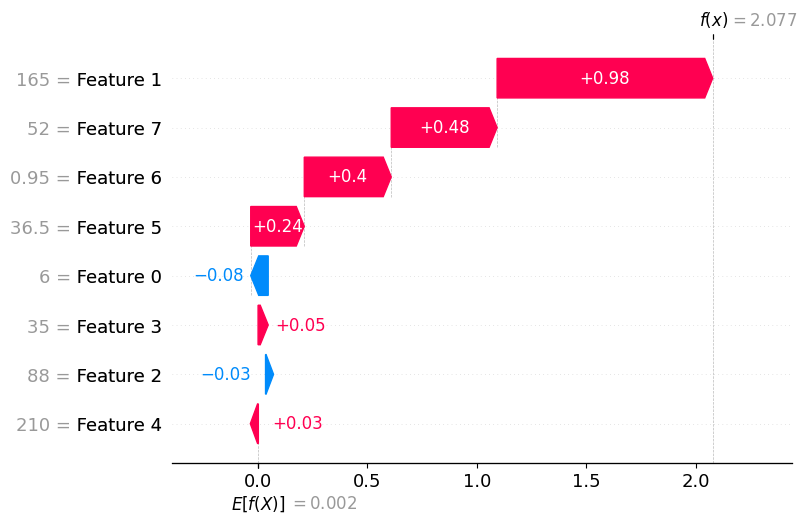

In [ ]:
import shap
import numpy as np

# Create SHAP explainer
explainer = shap.Explainer(final_model)

# Convert test_patient to numpy array
patient_array = np.array(test_patient).reshape(1, -1)

# Compute SHAP values
shap_values = explainer(patient_array)

# Plot
shap.plots.waterfall(shap_values[0])

Each bar shows how a feature moves the prediction up (red) or down (blue).

This plot explains why the model gave this particular prediction. It starts from the average prediction value of the model and then shows how each feature either increases or decreases that value for this specific sample. The red bars push the prediction higher, and the blue bars push it lower. By adding all these individual effects together, we get the final predicted value. So basically, this graph shows which features influenced the model the most for this one case and in which direction.